Found 8 cases
[1/8] 2025-10-04 01:00


/tmp/ipykernel_225523/3656841082.py:163: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0,0,0.88,1])


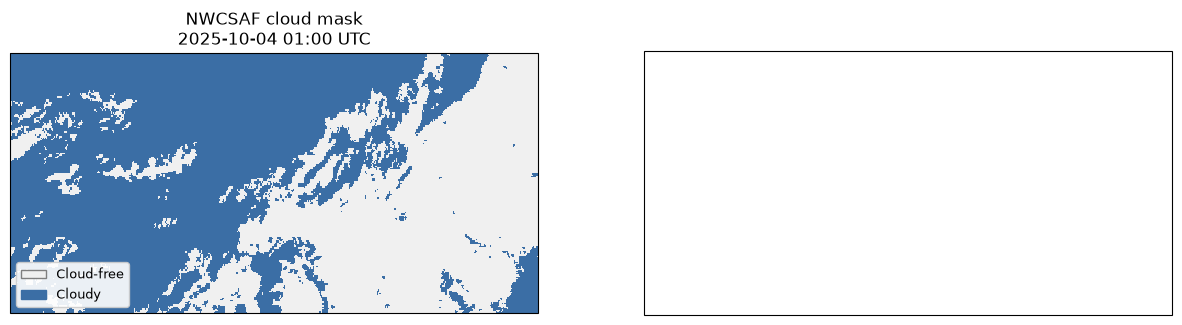

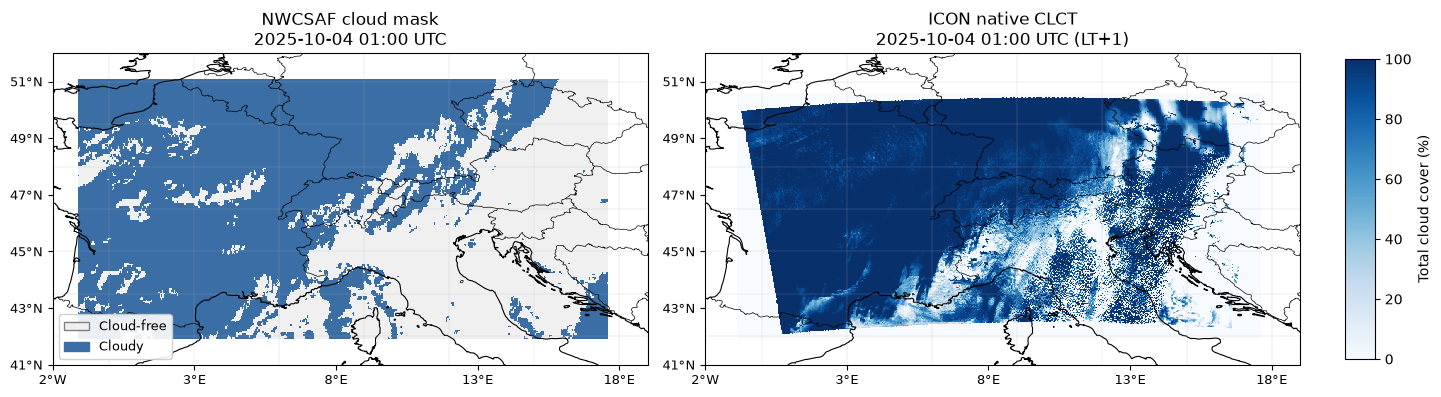

[2/8] 2025-10-04 04:00


/tmp/ipykernel_225523/3656841082.py:163: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0,0,0.88,1])


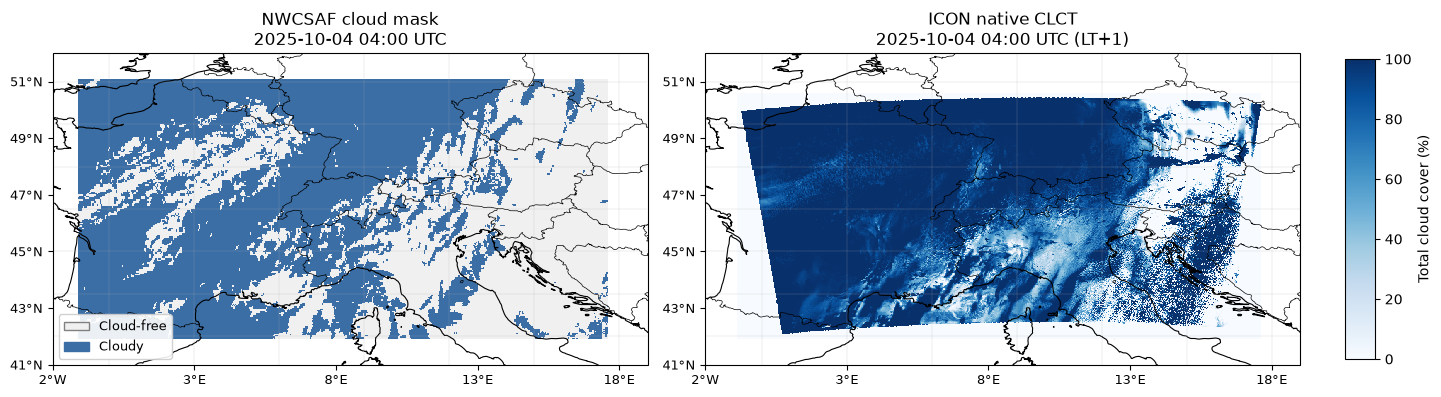

[3/8] 2025-10-04 07:00


/tmp/ipykernel_225523/3656841082.py:163: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0,0,0.88,1])


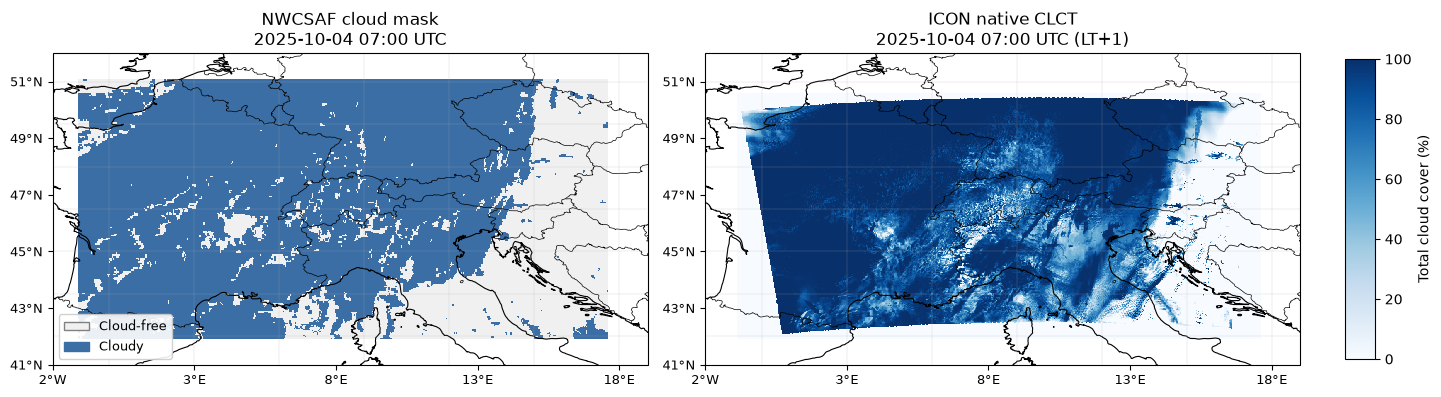

[4/8] 2025-10-04 10:00


/tmp/ipykernel_225523/3656841082.py:163: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0,0,0.88,1])


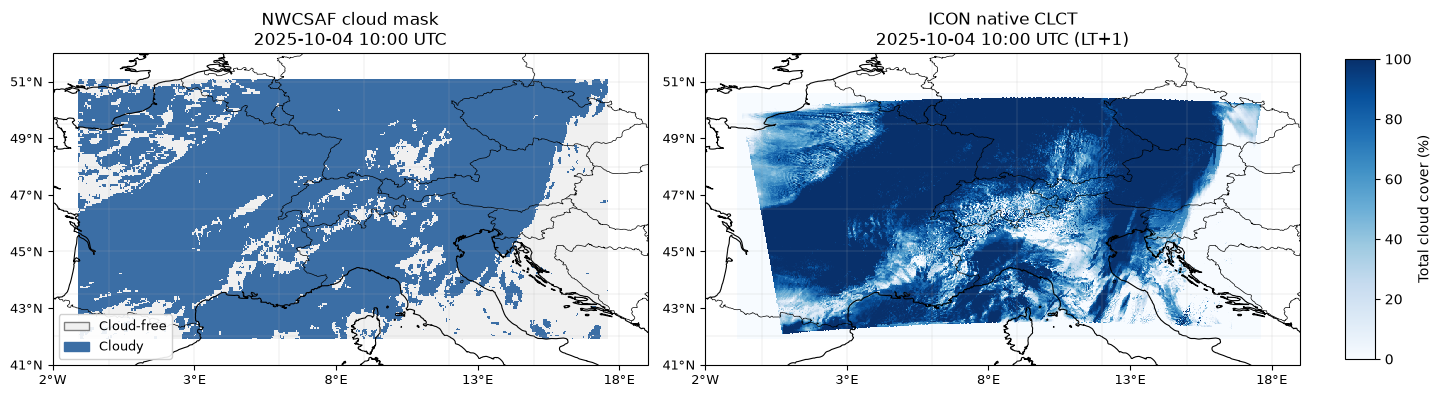

[5/8] 2025-10-04 13:00


/tmp/ipykernel_225523/3656841082.py:163: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0,0,0.88,1])


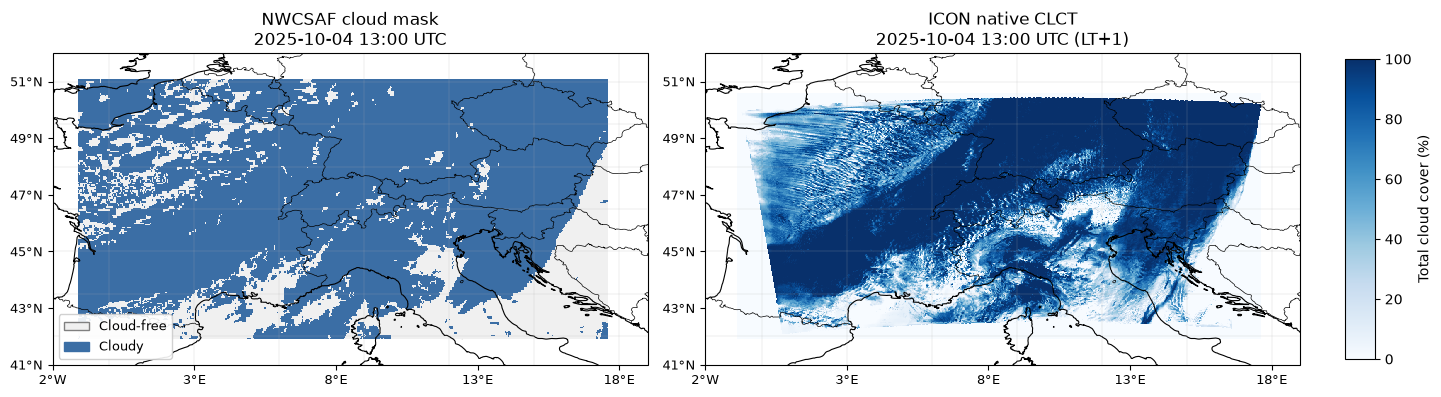

[6/8] 2025-10-04 16:00


/tmp/ipykernel_225523/3656841082.py:163: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0,0,0.88,1])


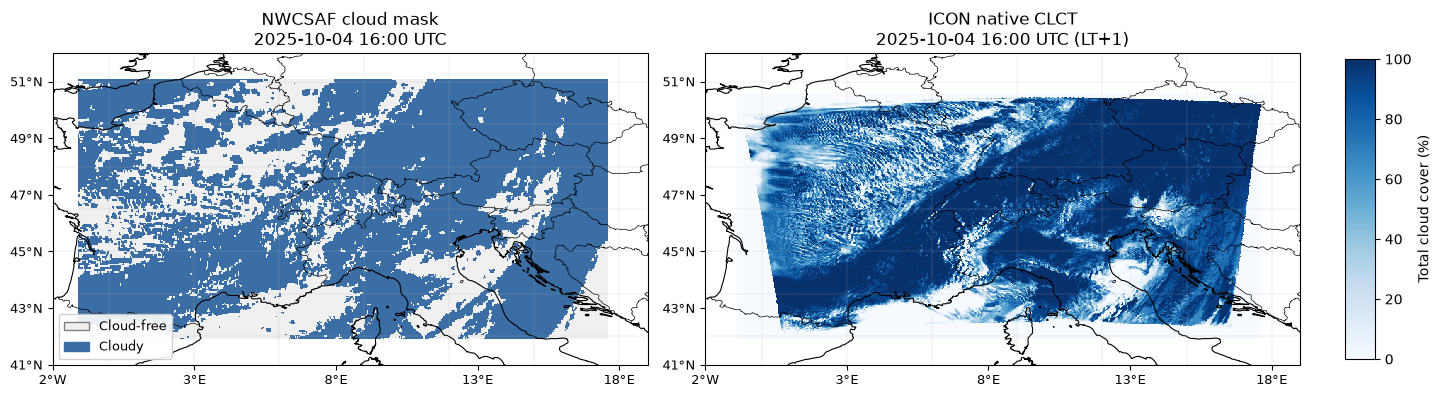

[7/8] 2025-10-04 19:00


/tmp/ipykernel_225523/3656841082.py:163: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0,0,0.88,1])


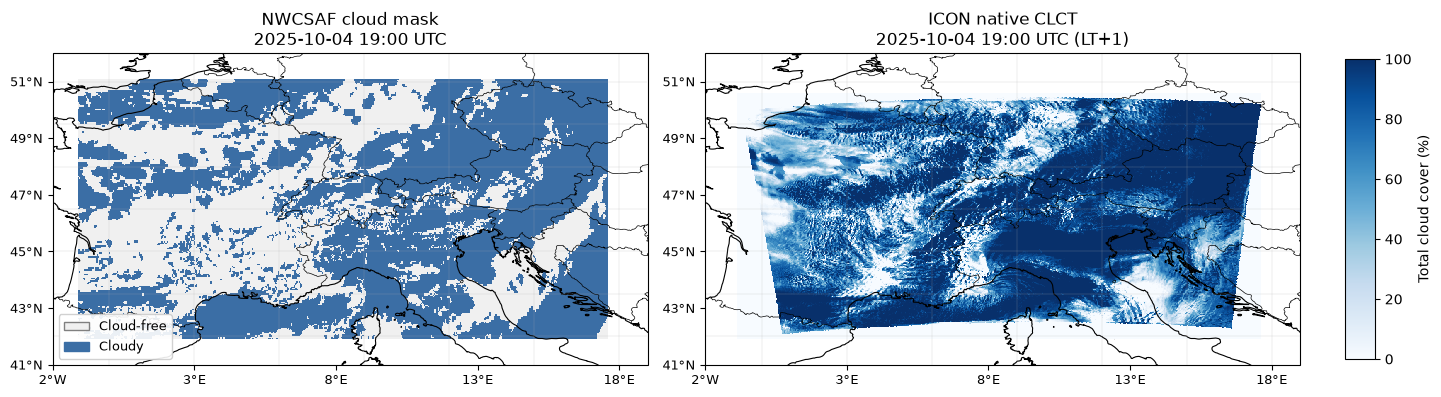

[8/8] 2025-10-04 22:00


/tmp/ipykernel_225523/3656841082.py:163: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0,0,0.88,1])


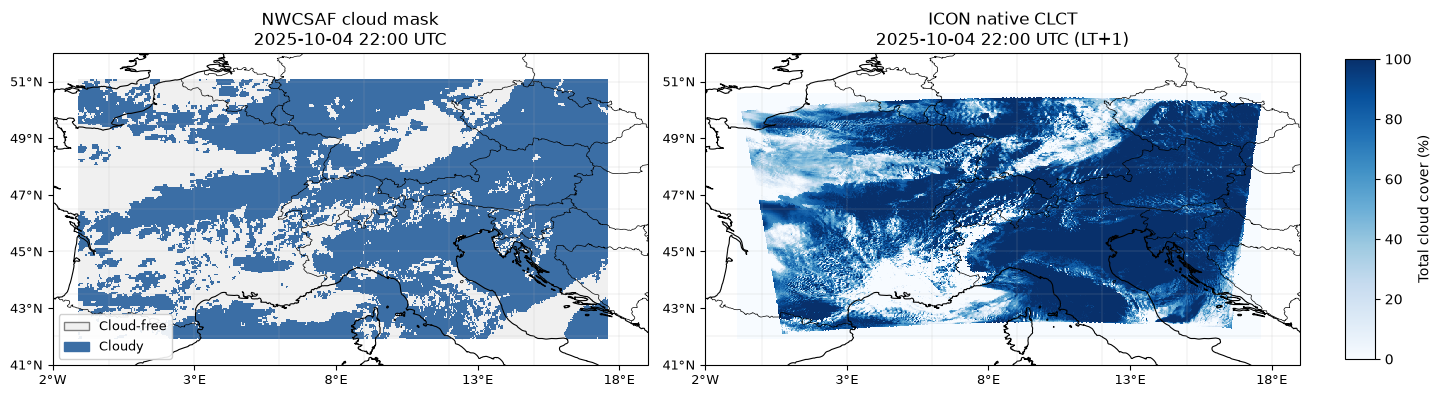

Done.


In [12]:
import os
os.environ["ECCODES_VERSION_CHECK_OFF"] = "1"

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from datetime import datetime, timedelta

from matplotlib.colors import ListedColormap, BoundaryNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

import earthkit.data as ekd

# ==========================================================
# SETTINGS
# ==========================================================

NWCSAF_DIR = "/scratch/mch/jdelbeke/nwcsaf"

RUN_SUFFIX = "638"
MEMBER = "000"
LEAD_HOURS = 1

SEARCH_START = datetime(2025, 10, 4, 0)
SEARCH_END   = datetime(2025, 10, 10, 23)

SAVE_FIGURES = True
SHOW_FIGURES = False

OUTPUT_DIR = os.path.expanduser("~/NWCSAF_ICON")

if SAVE_FIGURES:
    os.makedirs(OUTPUT_DIR, exist_ok=True)

# ==========================================================
# FIND FILES
# ==========================================================

def icon_base(run_time):
    return (
        f"/store_new/mch/msopr/osm/ICON-CH1-EPS/"
        f"FCST{run_time.year % 100:02d}")

def find_icon_file(run_time):
    icon_dir = os.path.join(
        icon_base(run_time),
        f"{run_time:%y%m%d%H}_{RUN_SUFFIX}",
        "grib")
    days, hours = divmod(LEAD_HOURS, 24)

    fname = (
        f"i1eff{days:02d}{hours:02d}0000_{MEMBER}")
    path = os.path.join(icon_dir, fname)
    return path if os.path.exists(path) else None


def find_nwcsaf_file(valid_time):
    fname = (
        f"MSG_nwcsaf_cosmo1eqc3km_"
        f"{valid_time:%Y%m%d%H%M}.nc")
    path = os.path.join(NWCSAF_DIR, fname)
    return path if os.path.exists(path) else None

# ==========================================================
# DISCOVER CASES
# ==========================================================

cases=[]
t=SEARCH_START

while t<=SEARCH_END:
    if t.hour%3==0:
        icon_file=find_icon_file(t)
        if icon_file:
            valid_time=t+timedelta(hours=LEAD_HOURS)
            nwcsaf_file=find_nwcsaf_file(valid_time)
            if nwcsaf_file:
                cases.append({"valid_time":valid_time,"icon_file":icon_file,"nwcsaf_file":nwcsaf_file})
    t+=timedelta(hours=1)

if not cases:
    raise FileNotFoundError("No matching ICON/NWCSAF files found")
print(f"Found {len(cases)} cases")


# ==========================================================
# LOOP THROUGH CASES
# ==========================================================

for i, case in enumerate(cases, start=1):
    valid_time=case["valid_time"]
    print(f"[{i}/{len(cases)}] {valid_time:%Y-%m-%d %H:%M}")
    
    # LOAD NWCSAF
    ds=xr.open_dataset(case["nwcsaf_file"])
    cma=ds["cma"].where(ds["cma"]!=255)
    lon_nwc=ds["longitude"].values; lat_nwc=ds["latitude"].values
    
    # LOAD ICON 
    fields=ekd.from_source("file",case["icon_file"]).to_fieldlist()
    clct_field=fields.sel({"parameter.variable":"CLCT"})[0]
    
    icon=clct_field.to_xarray()
    lon_icon=icon["longitude"].values; lat_icon=icon["latitude"].values; clct=icon["CLCT"].values
    


    # ------------------------------------------------------
    # PLOT
    # ------------------------------------------------------

    fig,axes=plt.subplots(1,2,figsize=(15,6),subplot_kw={"projection":ccrs.PlateCarree()})
    
    # NWCSAF
    cma_cmap=ListedColormap(["#f0f0f0","#3b6ea5"]); cma_norm=BoundaryNorm([-0.5,0.5,1.5],cma_cmap.N)
    axes[0].pcolormesh(lon_nwc,lat_nwc,cma,shading="auto",cmap=cma_cmap,norm=cma_norm,transform=ccrs.PlateCarree())
    axes[0].set_title(f"NWCSAF cloud mask\n{valid_time:%Y-%m-%d %H:%M UTC}")
    axes[0].legend(handles=[mpatches.Patch(color="#f0f0f0",label="Cloud-free",ec="0.5"),
                            mpatches.Patch(color="#3b6ea5",label="Cloudy")],loc="lower left",framealpha=.9,fontsize=9)
    
    # ICON
    sc=axes[1].scatter(lon_icon,lat_icon,c=clct,s=2,cmap="Blues",vmin=0,vmax=100,transform=ccrs.PlateCarree())
    axes[1].set_title(f"ICON native CLCT\n{valid_time:%Y-%m-%d %H:%M UTC} (LT+1)")

    # MAP SETTINGS
    for ax in axes:
        ax.set_extent([-2,19,41,52], crs=ccrs.PlateCarree())
        ax.coastlines(resolution="10m", linewidth=0.8)
        ax.add_feature(cfeature.BORDERS, linewidth=0.5)
        ax.gridlines(linewidth=0.3, alpha=0.5)
        ax.set_xticks(range(-2,20,5), crs=ccrs.PlateCarree())
        ax.set_yticks(range(41,53,2), crs=ccrs.PlateCarree())
        ax.xaxis.set_major_formatter(LongitudeFormatter())
        ax.yaxis.set_major_formatter(LatitudeFormatter())
        ax.tick_params(labelsize=9)

    # COLORBAR OUTSIDE PLOTS
    fig.subplots_adjust(right=0.88)
    cax=fig.add_axes([0.90,0.25,0.02,0.5])
    cbar=fig.colorbar(sc,cax=cax); cbar.set_label("Total cloud cover (%)")
    plt.tight_layout(rect=[0,0,0.88,1])
    
    # SAVE / SHOW
    if SAVE_FIGURES:
        plt.savefig(os.path.join(OUTPUT_DIR,f"NWCSAF_ICON_{valid_time:%Y%m%d_%H%M}.png"),dpi=200,bbox_inches="tight")
    
    if SHOW_FIGURES: plt.show()
    else: plt.close(fig)


print("Done.")